Modelo Identificador de Razas de Perros

Santiago Niño Amado

In [1]:
import urllib.request
import tarfile
import os

#  Descargar las imagenes
os.makedirs("/content/stanford_dogs", exist_ok=True)

print("⬇Descargando imágenes")
urllib.request.urlretrieve(
    "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar",
    "/content/stanford_dogs/images.tar"
)

print("Extrayendo")
with tarfile.open("/content/stanford_dogs/images.tar") as tar:
    tar.extractall(path="/content/stanford_dogs")

print("Listo, imágenes en /content (LOCAL)")


⬇Descargando imágenes
Extrayendo


/tmp/ipykernel_504/207411035.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content/stanford_dogs")


Listo, imágenes en /content (LOCAL)


In [2]:
import urllib.request
import tarfile
import os

#  Descargar las anotaciones de cada imagen
base_path = "/content/stanford_dogs"
os.makedirs(base_path, exist_ok=True)

print("⬇Descargando anotaciones")
url = "http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar"
urllib.request.urlretrieve(url, f"{base_path}/annotation.tar")

print("Extrayendo anotaciones")
with tarfile.open(f"{base_path}/annotation.tar") as tar:
    tar.extractall(path=base_path)

print("Anotaciones Descargadas")


⬇Descargando anotaciones
Extrayendo anotaciones


/tmp/ipykernel_504/2804500285.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=base_path)


Anotaciones Descargadas


In [3]:
import os

#Total del archivos
images_path = "/content/stanford_dogs/Images"
total = 0
for raza in os.listdir(images_path):
    raza_path = os.path.join(images_path, raza)

    if not os.path.isdir(raza_path):
        continue

    for img_file in os.listdir(raza_path):
        if img_file.endswith(".jpg"):
            total += 1

print(f"Total de imágenes: {total}")


Total de imágenes: 20580


In [4]:
import os
from PIL import Image
import xml.etree.ElementTree as ET
# se realiza el boxfind y el resize a las imagenes
# Rutas
images_path     = "/content/stanford_dogs/Images"
annotation_path = "/content/stanford_dogs/Annotation"

# Carpeta de salida
output_path = "/content/stanford_dogs_processed"
os.makedirs(output_path, exist_ok=True)

for raza in os.listdir(images_path):
    raza_img_path = os.path.join(images_path, raza)
    raza_ann_path = os.path.join(annotation_path, raza)

    if not os.path.isdir(raza_img_path):
        continue

    # 🔹 Crear carpeta por raza
    raza_output_path = os.path.join(output_path, raza)
    os.makedirs(raza_output_path, exist_ok=True)

    for img_file in os.listdir(raza_img_path):
        if not img_file.endswith(".jpg"):
            continue

        img_path = os.path.join(raza_img_path, img_file)
        ann_path = os.path.join(raza_ann_path, img_file.replace(".jpg", ""))

        try:
            # Leer bounding box
            tree = ET.parse(ann_path)
            root = tree.getroot()
            obj  = root.find('object')
            bbox = obj.find('bndbox')

            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            # Procesar imagen
            img = Image.open(img_path).convert("RGB")

            # Validación para evitar imágenes negras
            width, height = img.size
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(width, xmax)
            ymax = min(height, ymax)

            if xmin >= xmax or ymin >= ymax:
                print(f"⚠️ BBOX inválido en {img_file}, se omite")
                continue

            img = img.crop((xmin, ymin, xmax, ymax))
            img = img.resize((100, 100))

            # Guardar en carpeta local
            save_path = os.path.join(raza_output_path, img_file)
            img.save(save_path)

        except Exception as e:
            print(f"Error en {img_file}: {e}")

print("Imágenes guardadas en /content/stanford_dogs_processed")


Imágenes guardadas en /content/stanford_dogs_processed


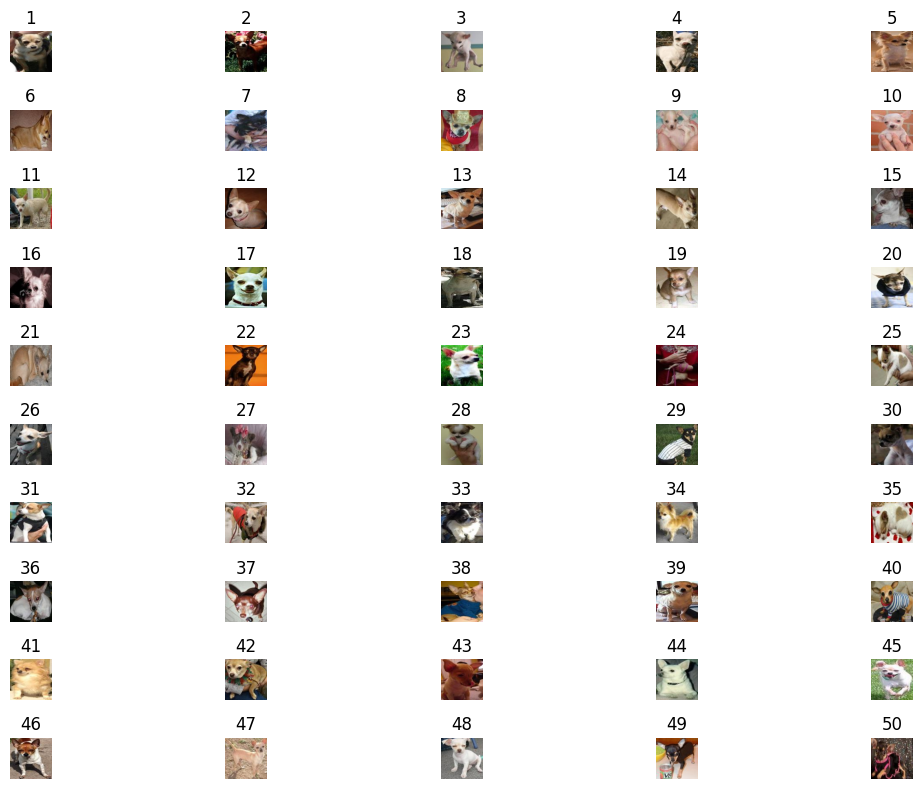

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image

processed_path = "/content/stanford_dogs_processed"
# se ve si se hizo correctamente el paso anterior
# Obtener todas las imágenes dentro de subcarpetas (por raza)
all_images = []

for raza in os.listdir(processed_path):
    raza_path = os.path.join(processed_path, raza)

    if not os.path.isdir(raza_path):
        continue

    for img_name in os.listdir(raza_path):
        if img_name.endswith(".jpg"):
            all_images.append(os.path.join(raza_path, img_name))

# 🔹 Ordenar y tomar primeras 30
all_images = sorted(all_images)[:50]

# 🔹 Mostrar
plt.figure(figsize=(12, 8))

for i, img_path in enumerate(all_images):
    img = Image.open(img_path)

    plt.subplot(10, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{i+1}")

plt.tight_layout()
plt.show()


In [6]:
import os

processed_path = "/content/stanford_dogs_processed"

total = 0

for raza in os.listdir(processed_path):
    raza_path = os.path.join(processed_path, raza)

    if not os.path.isdir(raza_path):
        continue

    for img_file in os.listdir(raza_path):
        if img_file.endswith(".jpg"):
            total += 1

print(f"Total de imágenes procesadas: {total}") #Total de imagenes procesadas


Total de imágenes procesadas: 20580


In [7]:
import os
from PIL import Image

processed_path = "/content/stanford_dogs_processed"

imagenes = []

# 🔹 Recorrer subcarpetas
for raza in os.listdir(processed_path):
    raza_path = os.path.join(processed_path, raza)

    if not os.path.isdir(raza_path):
        continue

    for img_name in os.listdir(raza_path):
        if img_name.endswith(".jpg"):
            imagenes.append(os.path.join(raza_path, img_name))

# 🔹 Tomar solo la primera imagen
primera = sorted(imagenes)[0]

# 🔹 Mostrar tamaño
img = Image.open(primera)
print(f"Imagen 1: {img.size}")  # (ancho, alto)

Imagen 1: (100, 100)


In [8]:
import tensorflow as tf

data_dir = "/content/stanford_dogs_processed"

# Se cargan las imágenes desde la carpeta procesada y se dividen en
# entrenamiento (90%) y validación (10%) usando la misma seed para
# que la división sea consistente y no haya fuga de datos entre splits.
# Se usan batches de 32 para no cargar todo el dataset en memoria a la vez.
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.1,   # 10% para validación
    subset="training",       # este dataset es el 90% de entrenamiento
    seed=42,                 # semilla fija → misma división siempre
    image_size=(100, 100),     # redimensiona todas las imágenes a 64×64
    batch_size=32            # 32 imágenes por batch
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.1,   # mismo 10%
    subset="validation",     # este dataset es ese 10% de validación
    seed=42,                 # misma seed → mismo 10% que se excluyó arriba
    image_size=(100, 100),
    batch_size=32
)

Found 20580 files belonging to 120 classes.
Using 18522 files for training.
Found 20580 files belonging to 120 classes.
Using 2058 files for validation.


In [9]:
# Se crea una capa de normalización que divide cada píxel entre 255,
# convirtiendo los valores del rango [0, 255] al rango [0.0, 1.0].
# Trabajar con valores pequeños estabiliza el entrenamiento y ayuda
# a que el gradiente no explote.
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Se aplica la normalización a cada batch del dataset usando .map().
# La función lambda separa imágenes (x) y etiquetas (y): normaliza x
# pero deja y intacto, ya que las etiquetas son índices enteros, no píxeles.
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [10]:
#Verifica la normlizacion
for images, labels in train_ds.take(1):  # toma 1 batch
    print("Valores originales:")
    print("min:", images.numpy().min(), "max:", images.numpy().max())

Valores originales:
min: 0.0 max: 1.0


In [11]:
import numpy as np

# Se concatenan todas las etiquetas del dataset de entrenamiento en un solo array
# y se obtienen los valores únicos para verificar que estén las 120 clases
labels_all = np.concatenate([y.numpy() for _, y in train_ds])

unique_labels = np.unique(labels_all)

print("Etiquetas únicas:", unique_labels)
print("Número de clases:", len(unique_labels))

Etiquetas únicas: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]
Número de clases: 120


In [12]:
import tensorflow as tf
from tensorflow.keras import layers

# Se define un pipeline de data augmentation como un modelo Sequential.
# Esto aplica transformaciones aleatorias a cada imagen durante el entrenamiento,
# generando variaciones artificiales del dataset para mejorar la generalización
# y reducir el overfitting, sin necesidad de conseguir más datos reales.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),      # Espeja la imagen horizontalmente con 50% de probabilidad
    layers.RandomRotation(0.05),          # Rota la imagen hasta ±5% (≈18°) aleatoriamente
    layers.RandomZoom(0.05),              # Aplica zoom de hasta ±5% aleatoriamente
    layers.RandomContrast(0.1),           # Ajusta el contraste aleatoriamente en un rango de ±10%
    layers.Lambda(lambda x:               # Recorta los valores al rango [0.0, 1.0] para evitar
        tf.clip_by_value(x, 0.0, 1.0))   # artefactos causados por las transformaciones anteriores
])

Original → min: 0.000  max: 1.000
RandomFlip → min: 0.000  max: 1.000
RandomRotation → min: 0.000  max: 1.000
RandomZoom → min: 0.000  max: 1.000
RandomContrast → min: 0.000  max: 1.000
Aug. completo 1 → min: 0.000  max: 1.000
Aug. completo 2 → min: 0.000  max: 1.000
Aug. completo 3 → min: 0.000  max: 1.000


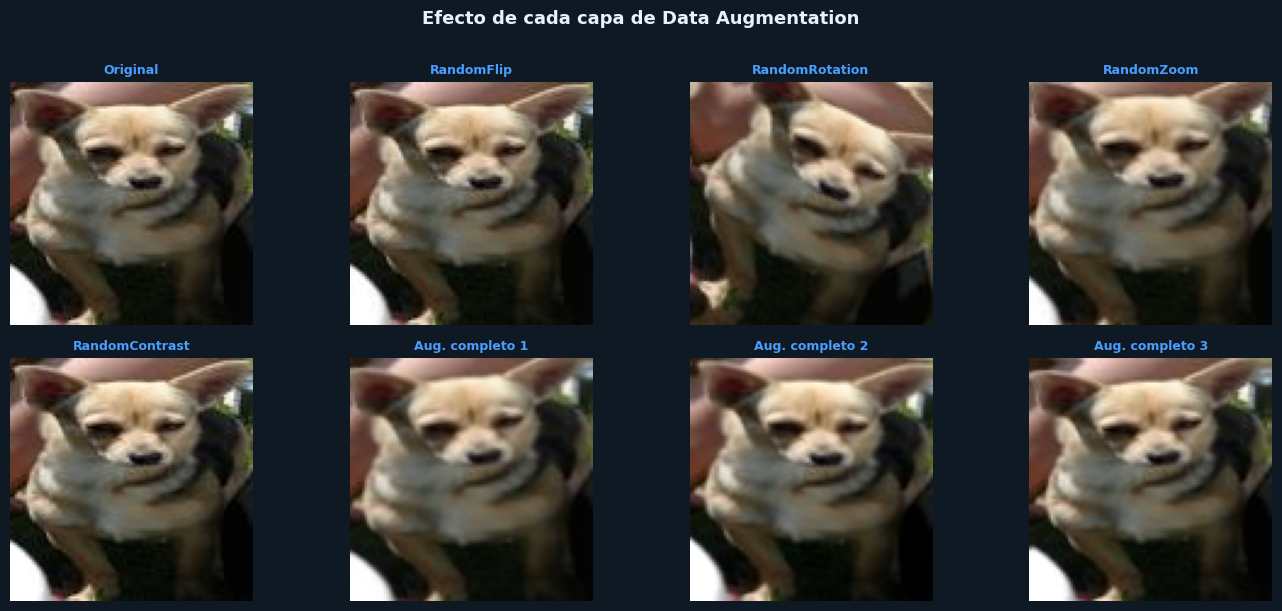

In [13]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

# Leer imagen directamente del disco, sin pasar por train_ds
base = "/content/stanford_dogs_processed"
primera_clase = sorted(os.listdir(base))[0]
primera_imagen = sorted(os.listdir(os.path.join(base, primera_clase)))[0]
img_path = os.path.join(base, primera_clase, primera_imagen)

# Cargar y normalizar manualmente
img_raw = tf.io.read_file(img_path)
img_original = tf.image.decode_jpeg(img_raw, channels=3)
img_original = tf.image.resize(img_original, [100, 100])
img_original = tf.cast(img_original, tf.float32) / 255.0  # [0.0, 1.0]

def aplicar(capa, img):
    out = capa(tf.expand_dims(img, 0))[0]
    return tf.clip_by_value(out, 0.0, 1.0)

transformaciones = [
    ("Original",        img_original),
    ("RandomFlip",      aplicar(layers.RandomFlip("horizontal"), img_original)),
    ("RandomRotation",  aplicar(layers.RandomRotation(0.15), img_original)),
    ("RandomZoom",      aplicar(layers.RandomZoom(0.2), img_original)),
    ("RandomContrast",  aplicar(layers.RandomContrast(0.4), img_original)),
    ("Aug. completo 1", aplicar(data_augmentation, img_original)),
    ("Aug. completo 2", aplicar(data_augmentation, img_original)),
    ("Aug. completo 3", aplicar(data_augmentation, img_original)),
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.patch.set_facecolor('#0f1923')

for ax, (titulo, img) in zip(axes.flat, transformaciones):
    arr = img.numpy()
    print(f"{titulo} → min: {arr.min():.3f}  max: {arr.max():.3f}")  # debug
    ax.imshow(arr)
    ax.set_title(titulo, color='#4a9eff', fontsize=9, fontweight='bold', pad=6)
    ax.axis('off')

fig.suptitle('Efecto de cada capa de Data Augmentation',
             color='#e8f0fe', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
from tensorflow.keras import layers
from tensorflow import keras

# Modelo CNN que recibe imágenes de 64×64×3 (RGB).
# Arquitectura:
#   - 2 bloques convolucionales: Conv2D(64) y Conv2D(128) con kernel 3×3
#   - Cada bloque usa LeakyReLU y MaxPooling para reducir dimensiones
#   - Aplanamiento (Flatten) para pasar de mapas 2D a vector 1D
#   - 2 capas densas ocultas: Dense(64) y Dense(32) con BatchNormalization
#   - Capa de salida: Dense(120, softmax) para clasificación de 120 razas

model = keras.Sequential([
    keras.Input(shape=(100, 100, 3)),
    data_augmentation,                               # Augmentation solo en entrenamiento


    layers.Conv2D(64, (3, 3), padding='same'),      # 128 filtros, kernel 3×3
    layers.LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2, 2)),                      # Reduce a 16×16

    layers.Conv2D(128, (3, 3), padding='same'),      # 128 filtros, kernel 3×3
    layers.LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2, 2)),                      # Reduce a 16×16

    layers.Conv2D(256, (3, 3), padding='same'),      # 128 filtros, kernel 3×3
    layers.LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2, 2)),                      # Reduce a 16×16

    layers.Flatten(),                                 # (16×16×128) → vector de 32768

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),                      # Estabiliza y acelera el entrenamiento

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(len(unique_labels), activation='softmax')  # 120 clases → probabilidades
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,359,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │         3,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,736,600 (10.44 MB)

 Trainable params: 2,736,408 (10.44 MB)

 Non-trainable params: 192 (768.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from google.colab import files
import os

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Guardar el mejor modelo en Colab
checkpoint = ModelCheckpoint(
    '/content/modelo_razas.keras',  # se guarda en Colab primero
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping, checkpoint]
)

# Descargar el modelo al PC automáticamente al terminar
files.download('/content/modelo_razas.keras')

Epoch 1/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0191 - loss: 4.7474
Epoch 1: val_loss improved from None to 4.53149, saving model to /content/modelo_razas.keras

Epoch 1: finished saving model to /content/modelo_razas.keras
579/579 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.0270 - loss: 4.6097 - val_accuracy: 0.0287 - val_loss: 4.5315
Epoch 2/50
578/579 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0496 - loss: 4.3495
Epoch 2: val_loss did not improve from 4.53149
579/579 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.0491 - loss: 4.3427 - val_accuracy: 0.0204 - val_loss: 5.3868
Epoch 3/50
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0600 - loss: 4.2263
Epoch 3: val_loss improved from 4.53149 to 4.32241, saving model to /content/modelo_razas.keras

Epoch 3: finished saving model to /content/modelo_razas.keras
579/579 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.0634 - loss: 4.1872 - val_accuracy: 0.0554 - val_loss: 4.3224
Epoch 4/50
578/579 ━

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

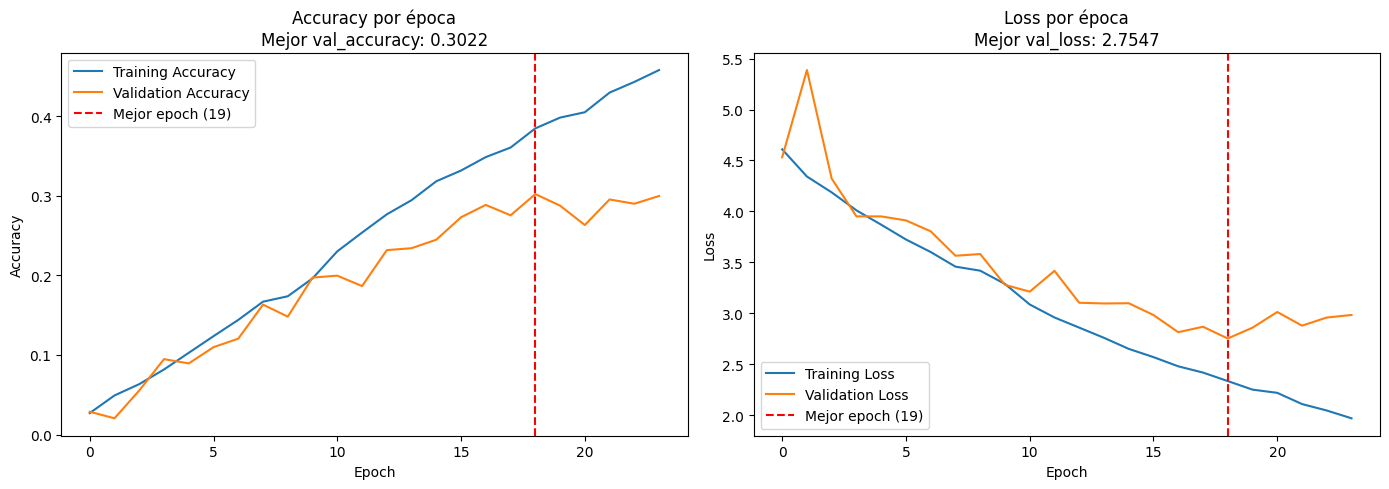

Mejor epoch:      19
Mejor val_loss:   2.7547
Mejor val_accuracy: 0.3022


In [16]:
# Se identifica el epoch con menor val_loss (mejor modelo guardado por el checkpoint)
best_epoch = np.argmin(history.history['val_loss'])
best_acc   = history.history['val_accuracy'][best_epoch]
best_loss  = history.history['val_loss'][best_epoch]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Accuracy
ax1.plot(history.history['accuracy'],     label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.axvline(best_epoch, color='red', linestyle='--', label=f'Mejor epoch ({best_epoch+1})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title(f'Accuracy por época\nMejor val_accuracy: {best_acc:.4f}')
ax1.legend()

# Gráfica de Loss
ax2.plot(history.history['loss'],     label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.axvline(best_epoch, color='red', linestyle='--', label=f'Mejor epoch ({best_epoch+1})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title(f'Loss por época\nMejor val_loss: {best_loss:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Mejor epoch:      {best_epoch+1}")
print(f"Mejor val_loss:   {best_loss:.4f}")
print(f"Mejor val_accuracy: {best_acc:.4f}")